In [1]:
#Here, we define 
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import *
import sympy
from sklearn.linear_model import LinearRegression
from sympy import re, im, I, E, symbols, exp
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import time

import tensorflow as tf

import glob
from tensorflow.keras.layers import Dense,Flatten,Cropping1D, Concatenate, MaxPooling1D, Dropout, Reshape, Conv1D, BatchNormalization, Activation, AveragePooling1D, GlobalAveragePooling1D, Lambda, Input, Concatenate, Add, UpSampling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras import losses
from tensorflow.keras.losses import Hinge
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard, ReduceLROnPlateau,LearningRateScheduler
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import Sequential
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.model_selection import KFold, train_test_split

from scipy.special import legendre
from scipy.special import chebyt, chebyu



import numpy as np
from scipy.special import pro_ang1
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
def Orders(s):

    # First we store the pairs

    Pairs = []
    
    for i in range(0, s + 1):   # x ranges from 0 to s
        for j in range(0, s + 1):  # y ranges from 0 to s
            if  (i+1)*(j+1) <= s+1:  # The HC condition
                Pairs.append((i, j))  # We add them

    return Pairs

In [3]:
#Number of samples and parameters

max_order_HC = 100 # increase to 20 or more eventually

w=8
Nsamples = np.linspace(10, 10000, 5).astype(int)
Ntest= 1000

Para_slep = [25]

total_runs = 1

In [4]:
Orders(10)

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (3, 0),
 (3, 1),
 (4, 0),
 (4, 1),
 (5, 0),
 (6, 0),
 (7, 0),
 (8, 0),
 (9, 0),
 (10, 0)]

In [5]:
#Define the samples in (x, y) format
def samps(t):
    """
    Generates random samples as (x, y) pairs.

    Parameters:
    t : int or list/ndarray
        The number of (x, y) pairs to generate.

    Returns:
    np.ndarray
        An array of shape (t, 2) where each row is an (x, y) pair.
    """
    # Determine total samples
    total_samples = int(t[0]) if isinstance(t, (list, np.ndarray)) else int(t)
    
    # Generate random (x, y) pairs
    Values = np.random.uniform(-1, 1, (total_samples, 2))
    
    return Values

In [6]:
import numpy as np

def sinc(x):
    # versión matemática clásica
    return np.where(x == 0, 1, np.sin(x) / x)


In [7]:
from scipy.interpolate import RegularGridInterpolator

def Grid(grid_range):
    nx=500
    ny=500
    """
    Compute the convolution of f(u,v) = sinc(u)*sinc(v) with
    h(u,v) = exp(-pi*(2.5 u^2 + 1.8 v^2 + 0.5 u v)) on a uniform grid
    using FFT 2D.
    
    Returns the grid vectors and the convolution values.
    """
    # --- Grid vectors ---
    x = np.linspace(-grid_range, grid_range, nx)
    y = np.linspace(-grid_range, grid_range, ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    # --- Evaluate f(u,v) ---
    f_grid = np.sin(x[None, :]) * np.sin(y[:, None])

    # --- Evaluate kernel h(u,v) ---
    U, V = np.meshgrid(x, y, indexing='ij')
    h_grid = np.exp(-np.pi * (2.5*U**2 + 1.8*V**2 + 0.3*U*V))

    # --- FFT convolution ---
    F_f = np.fft.fft2(f_grid)
    F_h = np.fft.fft2(h_grid)
    conv_fft = np.fft.ifft2(F_f * F_h).real * dx * dy
    conv_fft = np.fft.fftshift(conv_fft)

    return x, y, conv_fft
3

3

In [8]:
def funct(z, x, y, conv_grid, method='cubic'):
    """
    Interpolate convolution values at arbitrary points z
    using a precomputed grid.
    
    Parameters
    ----------
    z : ndarray of shape (n_points, 2)
        Points where to evaluate the convolution.
    x, y : 1D arrays
        Grid vectors.
    conv_grid : 2D array
        Convolution values on the grid.
    method : str
        Interpolation method ('linear' or 'cubic').
    
    Returns
    -------
    conv_values : ndarray of shape (n_points,)
    """
    interp = RegularGridInterpolator((x, y), conv_grid, method=method)
    conv_values = interp(z)
    return conv_values

In [9]:
'''
def funct(z):
    """
    Compute the convolution of g(x, y) = sinc(x)*sinc(y)*exp(-pi*(2.5*x^2 + 1.8*y^2 + 0.5*x*y))
    at the given points using a fixed grid for numerical integration.

    Parameters
    ----------
    xy_points : ndarray of shape (n_points, 2)
        Points (x_i, y_i) where the convolution should be evaluated.
    grid_range : float, optional
        The half-width of the grid in both x and y directions (default 3).
    nx, ny : int, optional
        Number of grid points in x and y (default 500).

    Returns
    -------
    conv_values : ndarray of shape (n_points,)
        Approximated convolution values at each xy_point.
    """
    grid_range=3, nx=500, ny=500
    
    # Generate grid for integration
    u = np.linspace(-grid_range, grid_range, nx)
    v = np.linspace(-grid_range, grid_range, ny)
    U, V = np.meshgrid(u, v)
    grid_points = np.column_stack([U.ravel(), V.ravel()])
    delta_u = u[1] - u[0]
    delta_v = v[1] - v[0]

    # Evaluate the original function on the grid
    xg, yg = z[:, 0], z[:, 1]
    f_grid = np.sinc(xg) * np.sinc(yg) 
    f_grid = f_grid.reshape(U.shape)

    # Compute convolution at each xy_point
    conv_values = np.zeros(xy_points.shape[0])
    for i, (x_i, y_i) in enumerate(xy_points):
        U_shifted = U - x_i
        V_shifted = V - y_i
        h_shifted = np.exp(-np.pi * (2.5*U_shifted**2 + 1.8*V_shifted**2 + 0.5*U_shifted*V_shifted))
        conv_values[i] = np.sum(f_grid * h_shifted) * delta_u * delta_v

    return conv_values
'''

'\ndef funct(z):\n    """\n    Compute the convolution of g(x, y) = sinc(x)*sinc(y)*exp(-pi*(2.5*x^2 + 1.8*y^2 + 0.5*x*y))\n    at the given points using a fixed grid for numerical integration.\n\n    Parameters\n    ----------\n    xy_points : ndarray of shape (n_points, 2)\n        Points (x_i, y_i) where the convolution should be evaluated.\n    grid_range : float, optional\n        The half-width of the grid in both x and y directions (default 3).\n    nx, ny : int, optional\n        Number of grid points in x and y (default 500).\n\n    Returns\n    -------\n    conv_values : ndarray of shape (n_points,)\n        Approximated convolution values at each xy_point.\n    """\n    grid_range=3, nx=500, ny=500\n\n    # Generate grid for integration\n    u = np.linspace(-grid_range, grid_range, nx)\n    v = np.linspace(-grid_range, grid_range, ny)\n    U, V = np.meshgrid(u, v)\n    grid_points = np.column_stack([U.ravel(), V.ravel()])\n    delta_u = u[1] - u[0]\n    delta_v = v[1] - v[0]

In [10]:
# This is the function that we approximate


def funct(z):
    """
    Function that computes a value based on the input coordinates (x, y).
    The function is of the form: cos(0.2 * x) * cos(0.2 * y) * exp(-pi * (x^2 + y^2)).

    Parameters:
    z : ndarray, shape (n_samples, 2)
        An array containing pairs of coordinates (x, y).

    Returns:
    g : ndarray, shape (n_samples,)
        The computed values of the function at each (x, y) pair.
    """
    
    # Extract coordinates
    x, y = z[:, 0], z[:, 1]

    # sinc(x) y sinc(y)
    sx = np.sinc(x)
    sy = np.sinc(y)

    #exponential term
    expo = np.exp(-np.pi*(x**2+y**2+0.2*x*y))

    # Final product l
    g =  expo
    return g



In [11]:
def Cheby(X, Y, j, k):
    """
    Evaluates the 2D Chebyshev polynomial T_j(x) * T_k(y) on 2D grids X and Y,
    normalized with the standard Chebyshev normalization.

    Parameters:
        X : ndarray
            2D array of x-values.
        Y : ndarray
            2D array of y-values (same shape as X).
        j : int
            Degree of Chebyshev polynomial in x.
        k : int
            Degree of Chebyshev polynomial in y.

    Returns:
        ndarray
            2D array of the same shape as X and Y with the evaluated polynomial.
    """
    norm_x = np.sqrt(np.pi) if j == 0 else np.sqrt(np.pi / 2)
    norm_y = np.sqrt(np.pi) if k == 0 else np.sqrt(np.pi / 2)

    Tx = chebyt(j)(X) / norm_x
    Ty = chebyt(k)(Y) / norm_y

    return Tx * Ty

In [12]:
def MatrixC(samp, k):
    """
    Computes a matrix A where each entry A[m, i] is the product of PSWF evaluated at g
    (x, y) in the given sample 'samp' for the 'i' order of the PSWF.
    """
    # Get the orders associated with the given 'k'
    Ords = Orders(k)

    # Initialize the matrix
    A = np.zeros((len(samp), len(Ords)))

    # Iterate through the sample points
    for m in range(len(samp)):
        x, y = samp[m]  # (x, y) coords of the m-th sample
        for i in range(len(Ords)):
            # Product of PSWF (or Chebyshev/Legendre depending on Cheby)
            A[m, i] = Cheby(x, y, Ords[i][0], Ords[i][1])

    return A


In [13]:
def Legend(X, Y, j, k):
    """
    Evaluates the 2D Legendre polynomial P_j(x) * P_k(y) on 2D grids X and Y,
    normalized with the standard L2 normalization.

    Parameters:
        X : ndarray
            2D array of x-values.
        Y : ndarray
            2D array of y-values (same shape as X).
        j : int
            Degree of Legendre polynomial in x.
        k : int
            Degree of Legendre polynomial in y.

    Returns:
        ndarray
            2D array of the same shape as X and Y with the evaluated polynomial.
    """
    # Normalization factors
    norm_x = np.sqrt(2 / (2 * j + 1))
    norm_y = np.sqrt(2 / (2 * k + 1))

    # Evaluate polynomials and normalize
    Px = legendre(j)(X) / norm_x
    Py = legendre(k)(Y) / norm_y

    return Px * Py


In [14]:
def MatrixL(samp, k):
    """
    Computes a matrix A where each entry A[m, i] is the product of PSWF evaluated at 
    (x, y) in the given sample 'samp' for the 'i' order of the PSWF.
    """
    # Get the orders associated with the given 'k'
    Ords = Orders(k)

    # Initialize the matrix
    A = np.zeros((len(samp), len(Ords)))

    # Iterate through the sample points
    for m in range(len(samp)):
        x, y = samp[m]  # (x, y) coords of the m-th sample
        for i in range(len(Ords)):
            # Product of PSWF (or Chebyshev/Legendre depending on Cheby)
            A[m, i] = Legend(x, y, Ords[i][0], Ords[i][1])

    return A


In [15]:
#Returns the multiple of the Slepian basis function

def NorSlep(j, c):
    b = 0 # Alpha parameter for the PSAF
    theta = np.linspace(-1, 1, 200)
    
    psaf_values = pro_ang1(b, j, c, theta)
    psaf_values = psaf_values[0] 
    
    psaf_values = psaf_values[1:199]
    l2_norm = np.linalg.norm(psaf_values)/np.sqrt(len(theta)-1)
    
    
    return l2_norm

norms_ = np.zeros((Para_slep[-1]+1))
for k in range(len(norms_)):
    norms_[k] = NorSlep(k, w)


In [16]:
# Function to compute the PSWF (Prolate Spheroidal Wave Function)
def PSWF(x, j, c):
    """
    Computes a multiple of the Prolate Spheroidal Wave Function (PSWF) at a given value of x.

    Parameters:
    x : float
        The point at which the PSWF is evaluated.
    j : int
        The index for the PSWF mode.
    c : float
        The constant related to the frequency parameter.
    norms_ : array-like
        Precomputed normalization constants for the PSWF modes.

    Returns:
    float
        The value of the PSWF at the point x, normalized by its L2 norm.
    """
    
    b = 0  # Alpha parameter for the PSAF (assumed to be 0 in this case)
    
    # Calculate the PSAF values for the given modes
    psaf_values = pro_ang1(b, j, c, x)
    
    # Extract the first value of the result 
    psaf_values = psaf_values[0]
    
    # Extract the normalization constant for the current mode
    l2_norm = norms_[j]
    
    # Return the normalized PSWF value
    return psaf_values / l2_norm



In [17]:
def product_of_pswf(x1, x2, i, j, c):
    """
    This function computes the product of two PSWFs with different indices j1 and j2
    evaluated at points x1 and x2, respectively, and normalizes the result.
    """
    pswf1 = PSWF(x1, i, c)

    # Compute the second PSWF at x2 with mode j2
    pswf2 = PSWF(x2, j, c)

    # Compute the product of both PSWFs
    product = pswf1 * pswf2

    # Return the product (this is already normalized)
    return product

In [18]:
def Matrix(samp, k):
    """
    Computes a matrix A where each entry A[m, i] is the product of PSWF evaluated at 
    (x, y) in the given sample 'samp' for the 'i' order of the PSWF.
    """
    # Get the orders associated with the given 'k'
    Ords = Orders(k)

    # Initialize the matrix
    A = np.zeros((len(samp), len(Ords)))

    # Iterate through the sample points
    for m in range(len(samp)):
        x, y = samp[m]  # (x, y) coords of the m-th sample
        for i in range(len(Ords)):
            # Product of PSWF (or Chebyshev/Legendre depending on Cheby)
            A[m, i] = product_of_pswf(x, y, Ords[i][0], Ords[i][1], w)

    return A

In [19]:
MSE_cheby = np.zeros([len(Para_slep), len(Nsamples), total_runs])
MSE_leg = np.zeros([len(Para_slep), len(Nsamples), total_runs])
MSE_slep = np.zeros([len(Para_slep), len(Nsamples), total_runs])



start_time = time.time()
total_iterations = total_runs * len(Para_slep) * len(Nsamples)
counter = 0
grid_range =3.0

x1, x2, gridConv = Grid(grid_range)

# test set can be the same always


for run in range(total_runs):
    # produce the matrix first, then take rectangles. It takes too long to recreate it every time.
    SamSet_ = samps(Nsamples[-1])  # Generate 2D samples
    y_ = funct(SamSet_)  # Compute function values for (x, y) pairs

    A_c_ = MatrixC(SamSet_, Para_slep[-1])
    A_l_ = MatrixL(SamSet_, Para_slep[-1])
    A_ = Matrix(SamSet_, Para_slep[-1])

    # Generate the test set
    TestSet = samps(Ntest)
    Values_test = funct(TestSet)
    
    test_cheby_matrix_ = MatrixC(TestSet, Para_slep[-1])
    test_leg_matrix_ = MatrixL(TestSet, Para_slep[-1])
    test_PSWF_matrix_ = Matrix(TestSet, Para_slep[-1])   
    


    for orde in range(len(Para_slep)):
        
        for k in range(len(Nsamples)):
            # Generate sample and test sets
            A_c = A_c_[:Nsamples[k], :]
            A_l = A_l_[:Nsamples[k], :]
            A_s = A_[:Nsamples[k], :]
            SamSet = SamSet_[:Nsamples[k]]
            y = y_[:Nsamples[k]]
            
            test_cheby_matrix = test_cheby_matrix_[:, :]
            test_leg_matrix = test_leg_matrix_[:, :]
            test_PSWF_matrix = test_PSWF_matrix_[:, :]
            Values_test = funct(TestSet)

            #Now for cheby

            # Solve the linear regression problem using lstsq (least squares)
            x =  np.linalg.lstsq(A_c, y, rcond=None)[0]
            print("Cheby")
            print(x)
            print(x.size)
            print(A_c.size)
            linear_combination_t = test_cheby_matrix@x             # Calculate the linear combination on the test set in a vectorized manner
            Err = np.linalg.norm(linear_combination_t - Values_test) / np.sqrt(Ntest) # Calculate the error
            MSE_cheby[orde, k, run] = Err


            #Then for legendre
            x =  np.linalg.lstsq(A_l, y, rcond=None)[0]
            print("Leg")
            print(x)
            print(x.size)
            print(A_l.size)
            linear_combination_t = test_leg_matrix@x             # Calculate the linear combination on the test set in a vectorized manner
            Err = np.linalg.norm(linear_combination_t - Values_test) / np.sqrt(Ntest) # Calculate the error
            MSE_leg[orde, k, run] = Err

            #Then for slepian
            x =  np.linalg.lstsq(A_s, y, rcond=None)[0]
            print("Slep")
            print(x)
            print(x.size)
            print(A_s.size)
            linear_combination_t = test_PSWF_matrix@x             # Calculate the linear combination on the test set in a vectorized manner
            Err = np.linalg.norm(linear_combination_t - Values_test) / np.sqrt(Ntest) # Calculate the error
            MSE_slep[orde, k, run] = Err

            counter += 1
            now_time = time.time()
            print('Error: ' + str(Err) +  ', Progress: ' + format(100*counter / total_iterations, '.2f') + '%' + ', approx. ' + format((total_iterations-counter)*(now_time -  start_time)/counter, '.1f') + ' seconds remaining.')
    
    
   

Cheby
[ 0.04865357  0.00854521 -0.03081005 -0.02212351 -0.01553387  0.02165583
  0.00092995 -0.02217072 -0.0030625   0.02516435  0.05362033 -0.01081271
 -0.05052835 -0.01013555 -0.00257606  0.03012137  0.01755124 -0.03503242
 -0.00055201  0.02768977  0.02054462 -0.02027303 -0.04881854  0.00062151
  0.01667676  0.0240645  -0.00789629 -0.00965346  0.01158877  0.0312531
  0.0016663  -0.02431599  0.0021506   0.01499023 -0.0072486  -0.01588318
 -0.01278848 -0.00526618  0.01791614 -0.04466223 -0.01622194  0.02383125
  0.02579595  0.00641541 -0.02939991  0.00797626  0.03330896  0.02583489
  0.0152933  -0.03508542 -0.04560211  0.01432382  0.04596353 -0.00180065
  0.02147529  0.01222942 -0.01789741  0.00033703 -0.02974564 -0.00873665
  0.04179778  0.02015141  0.01935722 -0.01421157 -0.02178885  0.01550431
  0.00624881 -0.02793902 -0.0211283   0.00345521  0.01317192 -0.00428078
  0.02043254  0.00110757 -0.02846318 -0.01280763  0.00212537  0.00172436
  0.0177882  -0.04138181 -0.00741944  0.057083

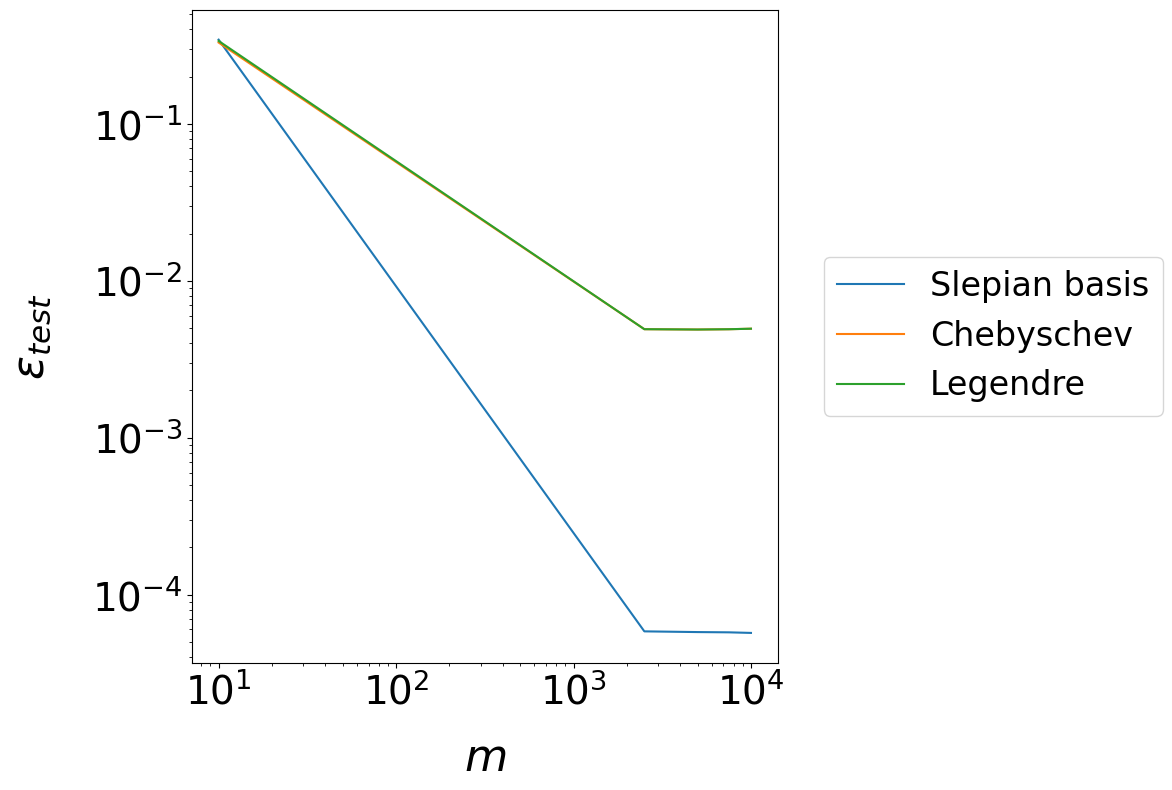

In [20]:
#Plot Error over training set sizes
plt.figure(figsize=(12, 8))  #Size
results_mean_cheby = np.mean(MSE_cheby, axis = 2)
results_lower_cheby = np.std(MSE_cheby, axis = 2)/results_mean_cheby # 90% confidence intervals

results_mean_leg = np.mean(MSE_leg, axis = 2)
results_lower_leg = np.std(MSE_leg, axis = 2)/results_mean_leg # 90% confidence intervals

results_mean = np.mean(MSE_slep, axis = 2)
results_lower= np.std(MSE_slep, axis = 2)/results_mean # 90% confidence intervals


for i in range(len(Para_slep)):
    plt.loglog(Nsamples, results_mean[i,:], label="Slepian basis")
    plt.fill_between(Nsamples, results_mean[i,:]/(1+results_lower[i,:]), results_mean[i,:]*(1+results_lower[i,:]),  alpha=0.2)

    plt.loglog(Nsamples, results_mean_cheby[i,:], label="Chebyschev")
    plt.fill_between(Nsamples, results_mean_cheby[i,:]/(1+results_lower_cheby[i,:]), results_mean_cheby[i,:]*(1+results_lower_cheby[i,:]),  alpha=0.2)

    plt.loglog(Nsamples, results_mean_leg[i,:], label="Legendre")
    plt.fill_between(Nsamples, results_mean_leg[i,:]/(1+results_lower_leg[i,:]), results_mean_leg[i,:]*(1+results_lower_leg[i,:]),  alpha=0.2)



plt.xlabel(r'$m$', fontsize=32, labelpad=18)
plt.ylabel(r'$\epsilon_{test}$', fontsize=32, labelpad=28)


# Increase font size of axis tick labels
plt.tick_params(axis='both', which='major', labelsize=28)  # Major ticks
plt.tick_params(axis='both', which='minor', labelsize=28)  # Minor ticks

plt.legend(fontsize=28, loc='lower left')

plt.legend(
    fontsize=24,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),  # Place the legend to the right of the plot
    ncol=1  # Single column for legend entries
)

plt.tight_layout()  

plt.savefig("errorvsparams2D_withNoy.pdf")


plt.show()


In [21]:
Para_slep

[25]

In [22]:
import os

# Número total de núcleos disponibles para Python
total_cores = os.cpu_count()
print("Núcleos totales:", total_cores)

Núcleos totales: 16
